# Load Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [2]:
2

2

# Load Data

In [3]:
train_data = pd.read_csv("./Data/train.csv")
train_data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train_data.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


Data fields

Here's a brief version of what you'll find in the data description file.

SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.

MSSubClass: The building class

MSZoning: The general zoning classification

LotFrontage: Linear feet of street connected to property

LotArea: Lot size in square feet

Street: Type of road access

Alley: Type of alley access

LotShape: General shape of property

LandContour: Flatness of the property

Utilities: Type of utilities available

LotConfig: Lot configuration

LandSlope: Slope of property

Neighborhood: Physical locations within Ames city limits

Condition1: Proximity to main road or railroad

Condition2: Proximity to main road or railroad (if a second is present)

BldgType: Type of dwelling

HouseStyle: Style of dwelling

OverallQual: Overall material and finish quality

OverallCond: Overall condition rating

YearBuilt: Original construction date

YearRemodAdd: Remodel date

RoofStyle: Type of roof

RoofMatl: Roof material

Exterior1st: Exterior covering on house

Exterior2nd: Exterior covering on house (if more than one material)

MasVnrType: Masonry veneer type

MasVnrArea: Masonry veneer area in square feet

ExterQual: Exterior material quality

ExterCond: Present condition of the material on the exterior

Foundation: Type of foundation

BsmtQual: Height of the basement

BsmtCond: General condition of the basement

BsmtExposure: Walkout or garden level basement walls

BsmtFinType1: Quality of basement finished area

BsmtFinSF1: Type 1 finished square feet

BsmtFinType2: Quality of second finished area (if present)

BsmtFinSF2: Type 2 finished square feet

BsmtUnfSF: Unfinished square feet of basement area

TotalBsmtSF: Total square feet of basement area

Heating: Type of heating

HeatingQC: Heating quality and condition

CentralAir: Central air conditioning

Electrical: Electrical system

1stFlrSF: First Floor square feet

2ndFlrSF: Second floor square feet

LowQualFinSF: Low quality finished square feet (all floors)

GrLivArea: Above grade (ground) living area square feet

BsmtFullBath: Basement full bathrooms

BsmtHalfBath: Basement half bathrooms

FullBath: Full bathrooms above grade

HalfBath: Half baths above grade

Bedroom: Number of bedrooms above basement level

Kitchen: Number of kitchens

KitchenQual: Kitchen quality

TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)

Functional: Home functionality rating

Fireplaces: Number of fireplaces

FireplaceQu: Fireplace quality

GarageType: Garage location

GarageYrBlt: Year garage was built

GarageFinish: Interior finish of the garage

GarageCars: Size of garage in car capacity

GarageArea: Size of garage in square feet

GarageQual: Garage quality

GarageCond: Garage condition

PavedDrive: Paved driveway

WoodDeckSF: Wood deck area in square feet

OpenPorchSF: Open porch area in square feet

EnclosedPorch: Enclosed porch area in square feet

3SsnPorch: Three season porch area in square feet

ScreenPorch: Screen porch area in square feet

PoolArea: Pool area in square feet

PoolQC: Pool quality

Fence: Fence quality

MiscFeature: Miscellaneous feature not covered in other categories

MiscVal: $Value of miscellaneous feature

MoSold: Month Sold

YrSold: Year Sold

SaleType: Type of sale

SaleCondition: Condition of sale



In [5]:
data_fields_meaning = {
    "SalePrice": "The property's sale price in dollars. Target variable",
    "MSSubClass": "The building class",
    "MSZoning": "The general zoning classification",
    "LotFrontage": "Linear feet of street connected to property",
    "LotArea": "Lot size in square feet",
    "Street": "Type of road access",
    "Alley": "Type of alley access",
    "LotShape": "General shape of property",
    "LandContour": "Flatness of the property",
    "Utilities": "Type of utilities available",
    "LotConfig": "Lot configuration",
    "LandSlope": "Slope of property",
    "Neighborhood": "Physical locations within Ames city limits",
    "Condition1": "Proximity to main road or railroad",
    "Condition2": "Proximity to main road or railroad (if a second is present)",
    "BldgType": "Type of dwelling",
    "HouseStyle": "Style of dwelling",
    "OverallQual": "Overall material and finish quality",
    "OverallCond": "Overall condition rating",
    "YearBuilt": "Original construction date",
    "YearRemodAdd": "Remodel date",
    "RoofStyle": "Type of roof",
    "RoofMatl": "Roof material",
    "Exterior1st": "Exterior covering on house",
    "Exterior2nd": "Exterior covering on house (if more than one material)",
    "MasVnrType": "Masonry veneer type",
    "MasVnrArea": "Masonry veneer area in square feet",
    "ExterQual": "Exterior material quality",
    "ExterCond": "Present condition of the material on the exterior",
    "Foundation": "Type of foundation",
    "BsmtQual": "Height of the basement",
    "BsmtCond": "General condition of the basement",
    "BsmtExposure": "Walkout or garden level basement walls",
    "BsmtFinType1": "Quality of basement finished area",
    "BsmtFinSF1": "Type 1 finished square feet",
    "BsmtFinType2": "Quality of second finished area (if present)",
    "BsmtFinSF2": "Type 2 finished square feet",
    "BsmtUnfSF": "Unfinished square feet of basement area",
    "TotalBsmtSF": "Total square feet of basement area",
    "Heating": "Type of heating",
    "HeatingQC": "Heating quality and condition",
    "CentralAir": "Central air conditioning",
    "Electrical": "Electrical system",
    "1stFlrSF": "First Floor square feet",
    "2ndFlrSF": "Second floor square feet",
    "LowQualFinSF": "Low quality finished square feet (all floors)",
    "GrLivArea": "Above grade living area square feet",
    "BsmtFullBath": "Basement full bathrooms",
    "BsmtHalfBath": "Basement half bathrooms",
    "FullBath": "Full bathrooms above grade",
    "HalfBath": "Half baths above grade",
    "Bedroom": "Number of bedrooms above basement level",
    "Kitchen": "Number of kitchens",
    "KitchenQual": "Kitchen quality",
    "TotRmsAbvGrd": "Total rooms above grade (excluding bathrooms)",
    "Functional": "Home functionality rating",
    "Fireplaces": "Number of fireplaces",
    "FireplaceQu": "Fireplace quality",
    "GarageType": "Garage location",
    "GarageYrBlt": "Year garage was built",
    "GarageFinish": "Interior finish of the garage",
    "GarageCars": "Garage size in car capacity",
    "GarageArea": "Garage size in square feet",
    "GarageQual": "Garage quality",
    "GarageCond": "Garage condition",
    "PavedDrive": "Paved driveway",
    "WoodDeckSF": "Wood deck area in square feet",
    "OpenPorchSF": "Open porch area in square feet",
    "EnclosedPorch": "Enclosed porch area in square feet",
    "3SsnPorch": "Three season porch area in square feet",
    "ScreenPorch": "Screen porch area in square feet",
    "PoolArea": "Pool area in square feet",
    "PoolQC": "Pool quality",
    "Fence": "Fence quality",
    "MiscFeature": "Miscellaneous feature not covered elsewhere",
    "MiscVal": "Value of miscellaneous feature",
    "MoSold": "Month sold",
    "YrSold": "Year sold",
    "SaleType": "Type of sale",
    "SaleCondition": "Condition of sale"
}

In [6]:
#Data fields

#Here's a brief version of what you'll find in the data description file.

print("SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.")
print(train_data['SalePrice'].describe())
print("\n\n\n----")

print("MSSubClass: The building class")
print(train_data['MSSubClass'].value_counts())
print("\n\n\n----")

print("MSZoning: The general zoning classification")
print(train_data['MSZoning'].value_counts())
print("\n\n\n----")


print("LotFrontage: Linear feet of street connected to property")
print(train_data['LotFrontage'].describe())
print("\n\n\n----")

print("LotArea: Lot size in square feet")
print(train_data['LotArea'].describe())
print("\n\n\n----")

print("Street: Type of road access")
print(train_data['Street'].value_counts())
print("\n\n\n----")

print("Alley: Type of alley access")
print(train_data['Alley'].value_counts())
print("\n\n\n----")


print("LotShape: General shape of property")
print(train_data['LotShape'].value_counts())
print("\n\n\n----")


print("LandContour: Flatness of the property")
print(train_data['LandContour'].value_counts())
print("\n\n\n----")


print("Utilities: Type of utilities available")
print(train_data['Utilities'].value_counts())
print("\n\n\n----")


print("LotConfig: Lot configuration")
print(train_data['LotConfig'].value_counts())
print("\n\n\n----")


print("LandSlope: Slope of property")
print(train_data['LandSlope'].value_counts())
print("\n\n\n----")


print("Neighborhood: Physical locations within Ames city limits")
print(train_data['Neighborhood'].value_counts())
print("\n\n\n----")


print("Condition1: Proximity to main road or railroad")
print(train_data['Condition1'].value_counts())
print("\n\n\n----")


print("Condition2: Proximity to main road or railroad (if a second is present)")
print(train_data['Condition2'].value_counts())
print("\n\n\n----")


print("BldgType: Type of dwelling")
print(train_data['BldgType'].value_counts())
print("\n\n\n----")


print("HouseStyle: Style of dwelling")
print(train_data['HouseStyle'].value_counts())
print("\n\n\n----")


print("OverallQual: Overall material and finish quality")
print(train_data['OverallQual'].value_counts())
print("\n\n\n----")


print("OverallCond: Overall condition rating")
print(train_data['OverallCond'].value_counts())
print("\n\n\n----")


print("YearBuilt: Original construction date")
print(train_data['YearBuilt'].value_counts())
print("\n\n\n----")


print("YearRemodAdd: Remodel date")
print(train_data['YearRemodAdd'].value_counts())
print("\n\n\n----")


print("RoofStyle: Type of roof")
print(train_data['RoofStyle'].value_counts())
print("\n\n\n----")


print("RoofMatl: Roof material")
print(train_data['RoofMatl'].value_counts())
print("\n\n\n----")


print("Exterior1st: Exterior covering on house")
print(train_data['Exterior1st'].value_counts())
print("\n\n\n----")


print("Exterior2nd: Exterior covering on house (if more than one material)")
print(train_data['Exterior2nd'].value_counts())
print("\n\n\n----")


print("MasVnrType: Masonry veneer type")
print(train_data['MasVnrType'].value_counts())
print("\n\n\n----")


print("MasVnrArea: Masonry veneer area in square feet")
print(train_data['MasVnrArea'].value_counts())
print("\n\n\n----")


print("ExterQual: Exterior material quality")
print(train_data['ExterQual'].value_counts())
print("\n\n\n----")


print("ExterCond: Present condition of the material on the exterior")
print(train_data['ExterCond'].value_counts())
print("\n\n\n----")


print("Foundation: Type of foundation")
print(train_data['Foundation'].value_counts())
print("\n\n\n----")


print("BsmtQual: Height of the basement")
print(train_data['BsmtQual'].value_counts())
print("\n\n\n----")


print("BsmtCond: General condition of the basement")
print(train_data['BsmtCond'].value_counts())
print("\n\n\n----")


print("BsmtExposure: Walkout or garden level basement walls")
print(train_data['BsmtExposure'].value_counts())
print("\n\n\n----")


print("BsmtFinType1: Quality of basement finished area")
print(train_data['BsmtFinType1'].value_counts())
print("\n\n\n----")


print("BsmtFinSF1: Type 1 finished square feet")
print(train_data['BsmtFinSF1'].value_counts())
print("\n\n\n----")


print("BsmtFinType2: Quality of second finished area (if present)")
print(train_data['BsmtFinType2'].value_counts())
print("\n\n\n----")


print("BsmtFinSF2: Type 2 finished square feet")
print(train_data['BsmtFinSF2'].value_counts())
print("\n\n\n----")


print("BsmtUnfSF: Unfinished square feet of basement area")
print(train_data['BsmtUnfSF'].value_counts())
print("\n\n\n----")


print("TotalBsmtSF: Total square feet of basement area")
print(train_data['TotalBsmtSF'].value_counts())
print("\n\n\n----")


print("Heating: Type of heating")
print(train_data['Heating'].value_counts())
print("\n\n\n----")


print("HeatingQC: Heating quality and condition")
print(train_data['HeatingQC'].value_counts())
print("\n\n\n----")


print("CentralAir: Central air conditioning")
print(train_data['CentralAir'].value_counts())
print("\n\n\n----")


print("Electrical: Electrical system")
print(train_data['Electrical'].value_counts())
print("\n\n\n----")


print("1stFlrSF: First Floor square feet")
print(train_data['1stFlrSF'].value_counts())
print("\n\n\n----")


print("2ndFlrSF: Second floor square feet")
print(train_data['2ndFlrSF'].value_counts())
print("\n\n\n----")


print("LowQualFinSF: Low quality finished square feet (all floors)")
print(train_data['LowQualFinSF'].value_counts())
print("\n\n\n----")


print("GrLivArea: Above grade (ground) living area square feet")
print(train_data['GrLivArea'].value_counts())
print("\n\n\n----")


print("BsmtFullBath: Basement full bathrooms")
print(train_data['BsmtFullBath'].value_counts())
print("\n\n\n----")


print("BsmtHalfBath: Basement half bathrooms")
print(train_data['BsmtHalfBath'].value_counts())
print("\n\n\n----")


print("FullBath: Full bathrooms above grade")
print(train_data['FullBath'].value_counts())
print("\n\n\n----")


print("HalfBath: Half baths above grade")
print(train_data['HalfBath'].value_counts())
print("\n\n\n----")


print("BedroomAbvGr: Number of bedrooms above basement level")
print(train_data['BedroomAbvGr'].value_counts())
print("\n\n\n----")


print("KitchenAbvGr: Number of kitchens")
print(train_data['KitchenAbvGr'].value_counts())
print("\n\n\n----")


print("KitchenQual: Kitchen quality")
print(train_data['KitchenQual'].value_counts())
print("\n\n\n----")


print("TotRmsAbvGrd: Total rooms above grade (does not include bathrooms)")
print(train_data['TotRmsAbvGrd'].value_counts())
print("\n\n\n----")


print("Functional: Home functionality rating")
print(train_data['Functional'].value_counts())
print("\n\n\n----")


print("Fireplaces: Number of fireplaces")
print(train_data['Fireplaces'].value_counts())
print("\n\n\n----")


print("FireplaceQu: Fireplace quality")
print(train_data['FireplaceQu'].value_counts())
print("\n\n\n----")


print("GarageType: Garage location")
print(train_data['GarageType'].value_counts())
print("\n\n\n----")


print("GarageYrBlt: Year garage was built")
print(train_data['GarageYrBlt'].value_counts())
print("\n\n\n----")


print("GarageFinish: Interior finish of the garage")
print(train_data['GarageFinish'].value_counts())
print("\n\n\n----")


print("GarageCars: Size of garage in car capacity")
print(train_data['GarageCars'].describe())
print("\n\n\n----")


print("GarageArea: Size of garage in square feet")
print(train_data['GarageArea'].describe())
print("\n\n\n----")


print("GarageQual: Garage quality")
print(train_data['GarageQual'].value_counts())
print("\n\n\n----")


print("GarageCond: Garage condition")
print(train_data['GarageCond'].value_counts())
print("\n\n\n----")


print("PavedDrive: Paved driveway")
print(train_data['PavedDrive'].value_counts())
print("\n\n\n----")


print("WoodDeckSF: Wood deck area in square feet")
print(train_data['WoodDeckSF'].describe())
print("\n\n\n----")


print("OpenPorchSF: Open porch area in square feet")
print(train_data['OpenPorchSF'].describe())
print("\n\n\n----")

      
print("EnclosedPorch: Enclosed porch area in square feet")
print(train_data['EnclosedPorch'].describe())
print("\n\n\n----")


print("3SsnPorch: Three season porch area in square feet")
print(train_data['3SsnPorch'].describe())
print("\n\n\n----")


print("ScreenPorch: Screen porch area in square feet")
print(train_data['ScreenPorch'].describe())
print("\n\n\n----")


print("PoolArea: Pool area in square feet")
print(train_data['PoolArea'].describe())
print("\n\n\n----")


print("PoolQC: Pool quality")
print(train_data['PoolQC'].value_counts())
print("\n\n\n----")


print("Fence: Fence quality")
print(train_data['Fence'].value_counts())
print("\n\n\n----")


print("MiscFeature: Miscellaneous feature not covered in other categories")
print(train_data['MiscFeature'].value_counts())
print("\n\n\n----")


print("MiscVal: $Value of miscellaneous feature")
print(train_data['MiscVal'].describe())
print("\n\n\n----")


print("MoSold: Month Sold")
print(train_data['MoSold'].value_counts())
print("\n\n\n----")


print("YrSold: Year Sold")
print(train_data['YrSold'].value_counts())
print("\n\n\n----")


print("SaleType: Type of sale")
print(train_data['SaleType'].value_counts())
print("\n\n\n----")


print("SaleCondition: Condition of sale")
print(train_data['SaleCondition'].value_counts())
print("\n\n\n----")




SalePrice - the property's sale price in dollars. This is the target variable that you're trying to predict.
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64



----
MSSubClass: The building class
MSSubClass
20     536
60     299
50     144
120     87
30      69
160     63
70      60
80      58
90      52
190     30
85      20
75      16
45      12
180     10
40       4
Name: count, dtype: int64



----
MSZoning: The general zoning classification
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64



----
LotFrontage: Linear feet of street connected to property
count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64


In [7]:

print("Bedroom: Number of bedrooms above basement level")
#print(train_data['Bedroom'].value_counts())
print("\n\n\n----")
train_data.columns

Bedroom: Number of bedrooms above basement level



----


Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

## Let us convert Data Type of relevant columns

In [8]:
train_data.describe().columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [9]:
train_data['MSSubClass'] = train_data['MSSubClass'].astype("str")
train_data['Age'] = 2025 - train_data['YearBuilt']
train_data["remodel_age"] = 2026 - train_data['YearRemodAdd']
train_data["BsmtFullBath"] = train_data["BsmtFullBath"].astype(str)
train_data['Age_Of_Garage'] = 2026 - train_data["GarageYrBlt"]
train_data['Sales_Age'] = 2026 - train_data["YrSold"]
train_data['MoSold'] = train_data['MoSold'].astype("str")

In [10]:
train_data.drop(columns=["YearBuilt","YearRemodAdd","GarageYrBlt","YrSold","Id"],inplace=True)

In [11]:
continous_variables = set(train_data.describe().columns)
categorical_variables = set(train_data.columns).difference(continous_variables)

In [13]:
train_data[list(categorical_variables)]

,BldgType,RoofStyle,GarageFinish,Neighborhood,ExterQual,BsmtExposure,FireplaceQu,Foundation,Alley,ExterCond,...,MSSubClass,Functional,BsmtCond,PavedDrive,Condition2,MoSold,MiscFeature,Heating,SaleType,HeatingQC
0,1Fam,Gable,RFn,CollgCr,Gd,No,NaN,PConc,NaN,TA,...,60,Typ,TA,Y,Norm,2,NaN,GasA,WD,Ex
1,1Fam,Gable,RFn,Veenker,TA,Gd,TA,CBlock,NaN,TA,...,20,Typ,TA,Y,Norm,5,NaN,GasA,WD,Ex
2,1Fam,Gable,RFn,CollgCr,Gd,Mn,TA,PConc,NaN,TA,...,60,Typ,TA,Y,Norm,9,NaN,GasA,WD,Ex
3,1Fam,Gable,Unf,Crawfor,TA,No,Gd,BrkTil,NaN,TA,...,70,Typ,Gd,Y,Norm,2,NaN,GasA,WD,Gd
4,1Fam,Gable,RFn,NoRidge,Gd,Av,TA,PConc,NaN,TA,...,60,Typ,TA,Y,Norm,12,NaN,GasA,WD,Ex
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1Fam,Gable,RFn,Gilbert,TA,No,TA,PConc,NaN,TA,...,60,Typ,TA,Y,Norm,8,NaN,GasA,WD,Ex
1456,1Fam,Gable,Unf,NWAmes,TA,No,TA,CBlock,NaN,TA,...,20,Min1,TA,Y,Norm,2,NaN,GasA,WD,TA
1457,1Fam,Gable,RFn,Crawfor,Ex,No,Gd,Stone,NaN,Gd,...,70,Typ,Gd,Y,Norm,5,Shed,GasA,WD,Ex
1458,1Fam,Hip,Unf,NAmes,TA,Mn,NaN,CBlock,NaN,TA,...,20,Typ,TA,Y,Norm,4,NaN,GasA,WD,Gd


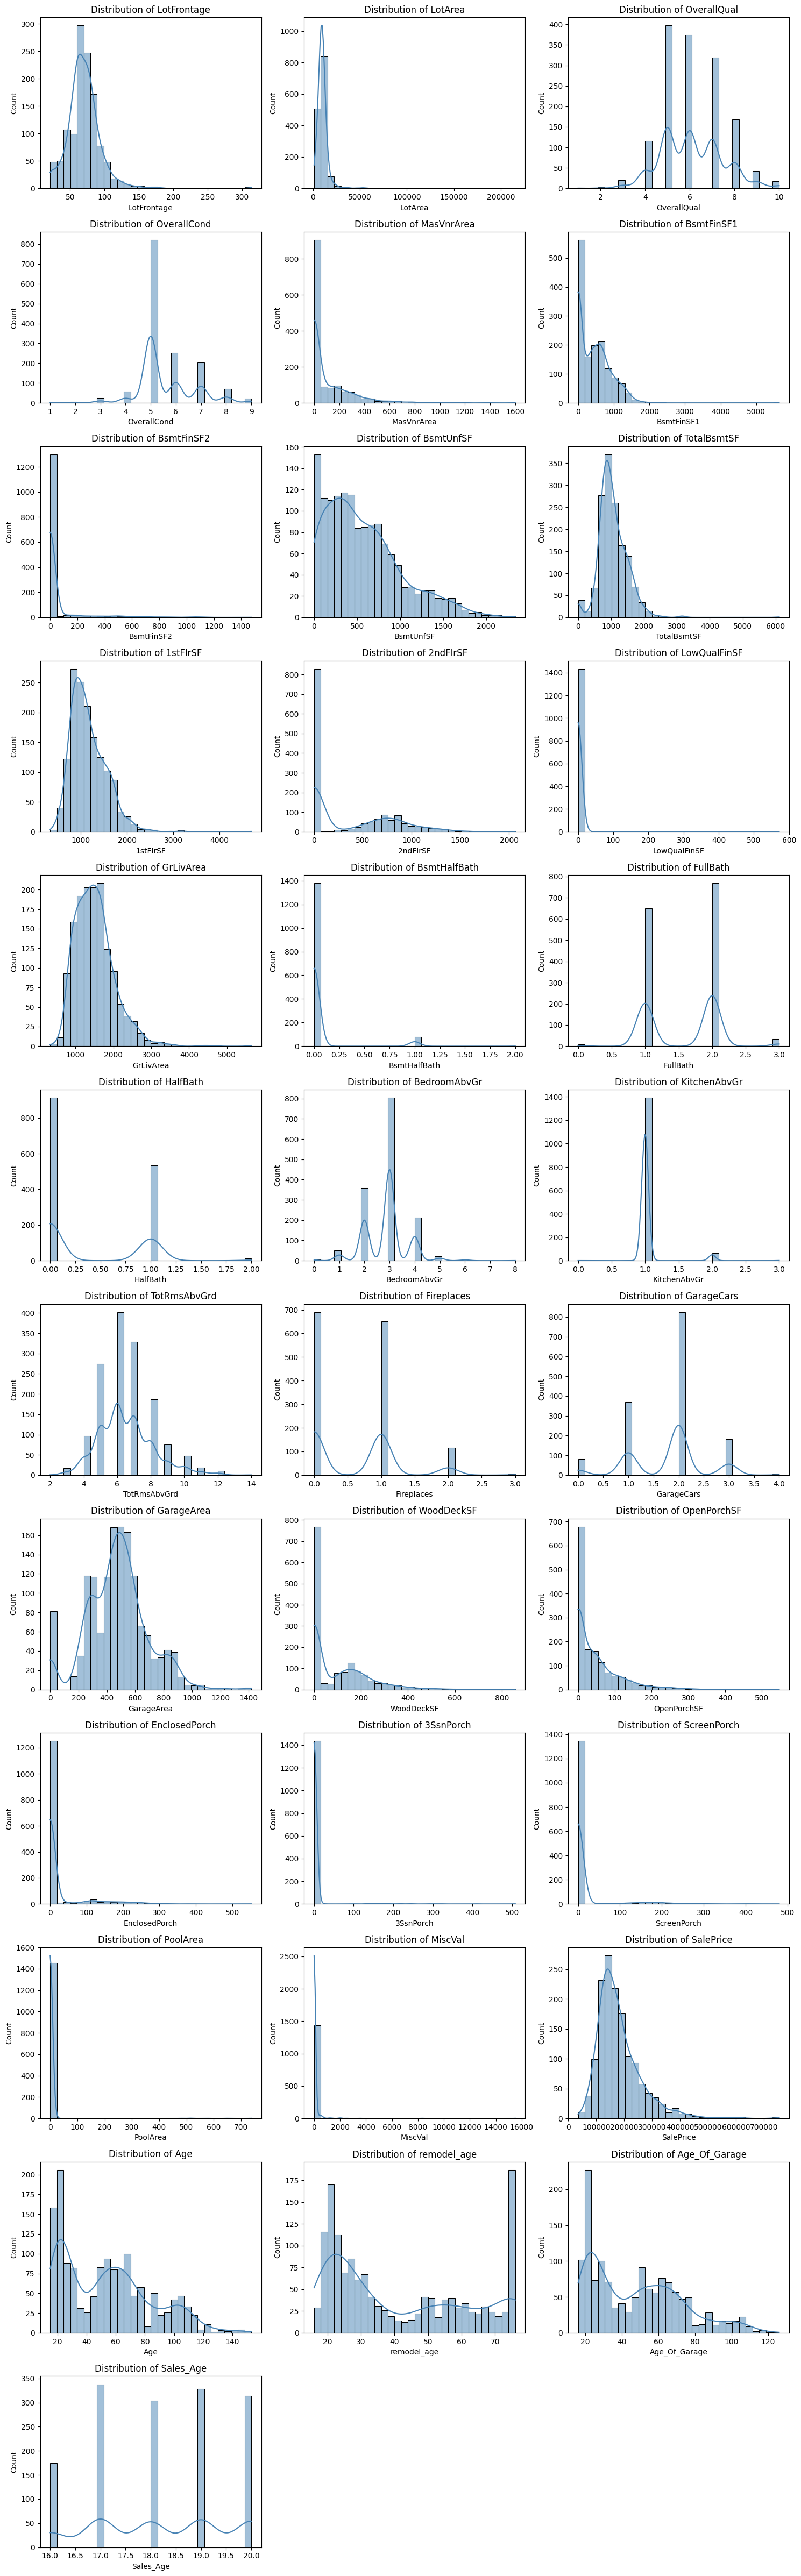

In [14]:
# Select only numeric columns
num_cols = train_data.select_dtypes(include=['float', 'int']).columns
n = len(num_cols)

# Define subplot grid size
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(train_data[col], kde=True, ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(f'Distribution of {col}')

# Turn off empty subplots
for i in range(n, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Removal based on correlation

In [14]:
corr = train_data[list(continous_variables)].corr()["SalePrice"].sort_values(ascending=False)
print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
3SsnPorch        0.044584
Sales_Age        0.028923
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Age_Of_Garage   -0.486362
remodel_age     -0.507101
Age             -0.522897
Name: SalePrice, dtype: float64


In [15]:
cols_to_remove_based_on_correlaation = ["3SsnPorch", "Sales_Age", "BsmtFinSF2", "BsmtHalfBath", "MiscVal", "LowQualFinSF"]

### Removal based on multi-collinearity

In [16]:
corr_matrix = train_data[list(continous_variables)].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

columns_to_drop_for_multi_collinearity = [column for column in upper.columns if any(upper[column] > 0.8)]

In [17]:
columns_to_drop_for_multi_collinearity

['Age', 'GarageCars', 'TotRmsAbvGrd', 'TotalBsmtSF']

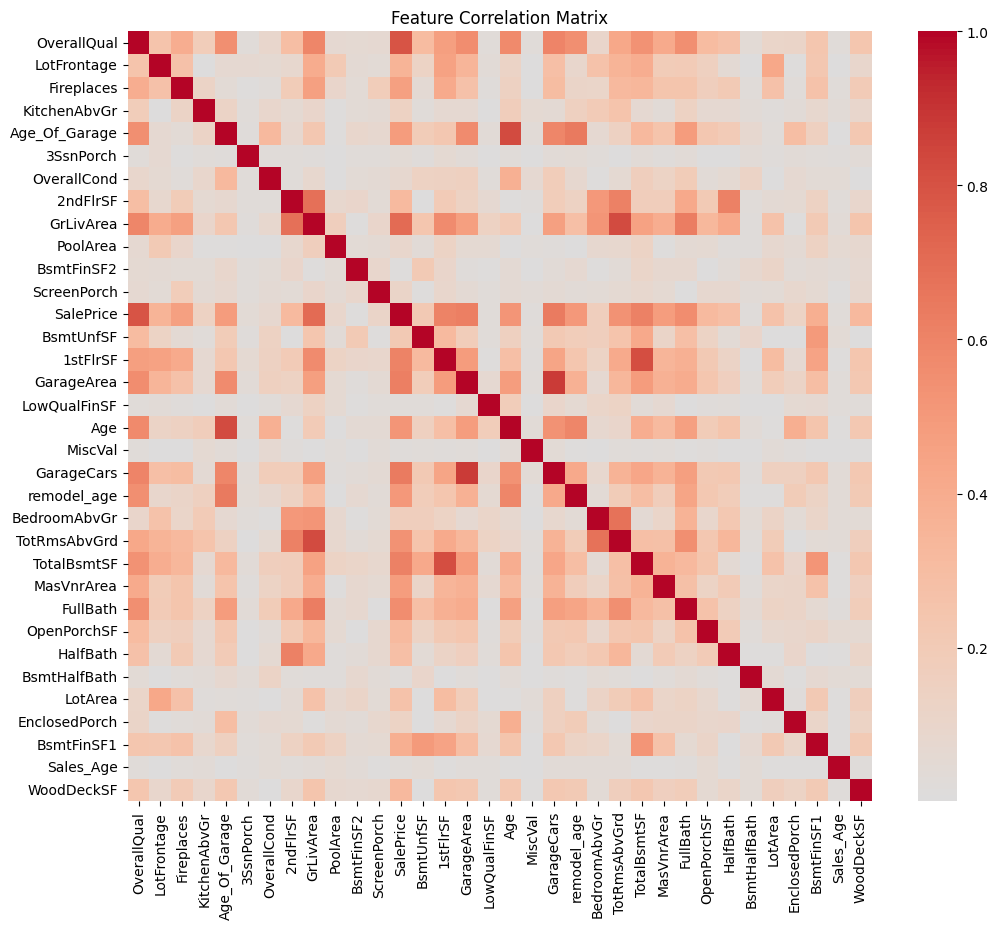

In [20]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

### Check missing values

In [27]:
pd.set_option('display.max_rows', None)
print(train_data.isnull().sum().sort_values(ascending=False))

PoolQC           1453
MiscFeature      1406
Fence            1179
MasVnrType        872
FireplaceQu       690
LotFrontage       259
GarageType         81
GarageQual         81
GarageCond         81
Age_Of_Garage      81
GarageFinish       81
BsmtExposure       38
BsmtFinType2       38
BsmtCond           37
BsmtFinType1       37
BsmtQual           37
MasVnrArea          8
Electrical          1
BedroomAbvGr        0
Fireplaces          0
GarageCars          0
Functional          0
TotRmsAbvGrd        0
KitchenQual         0
KitchenAbvGr        0
HalfBath            0
MSSubClass          0
GarageArea          0
MiscVal             0
remodel_age         0
Age                 0
SalePrice           0
SaleCondition       0
SaleType            0
MoSold              0
PoolArea            0
BsmtHalfBath        0
ScreenPorch         0
3SsnPorch           0
EnclosedPorch       0
OpenPorchSF         0
WoodDeckSF          0
PavedDrive          0
FullBath            0
1stFlrSF            0
BsmtFullBa

In [26]:
train_data.shape

for k in 
train_data['Alley'] = np.where(train_data['Alley'].isna(),"Not_Available",train_data['Alley'])

In [28]:
missing_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu"]
for j in missing_cols:
    train_data[j] = np.where(train_data[j].isna(),"Not_Available",train_data[j])

In [22]:
set(columns_to_drop_for_multi_collinearity)

{'Age', 'GarageCars', 'TotRmsAbvGrd', 'TotalBsmtSF'}

In [29]:
missing_cols = ["PoolQC", "MiscFeature"]

remove_cols = list(set(missing_cols) | set(cols_to_remove_based_on_correlaation) | set(columns_to_drop_for_multi_collinearity))

print(remove_cols)

train_data.drop(columns=remove_cols,inplace=True)

['PoolQC', 'BsmtFinSF2', 'LowQualFinSF', 'Age', 'BsmtHalfBath', '3SsnPorch', 'MiscVal', 'Sales_Age', 'GarageCars', 'MiscFeature', 'TotRmsAbvGrd', 'TotalBsmtSF']


In [30]:
# Drop cols with mostly missing values

print(missing_cols)
print(cols_to_remove_based_on_correlaation)
print(columns_to_drop_for_multi_collinearity)



['PoolQC', 'MiscFeature']
['3SsnPorch', 'Sales_Age', 'BsmtFinSF2', 'BsmtHalfBath', 'MiscVal', 'LowQualFinSF']
['Age', 'GarageCars', 'TotRmsAbvGrd', 'TotalBsmtSF']


In [31]:
continous_variables = set(train_data.describe().columns)
categorical_variables = set(train_data.columns).difference(continous_variables)

continous_variables = list(continous_variables)
categorical_variables = list(categorical_variables)

train_data[continous_variables] = train_data[continous_variables].fillna(train_data[continous_variables].mean())
train_data[categorical_variables] = train_data[categorical_variables].fillna(train_data[categorical_variables].mode().iloc[0])

## Check Outliers

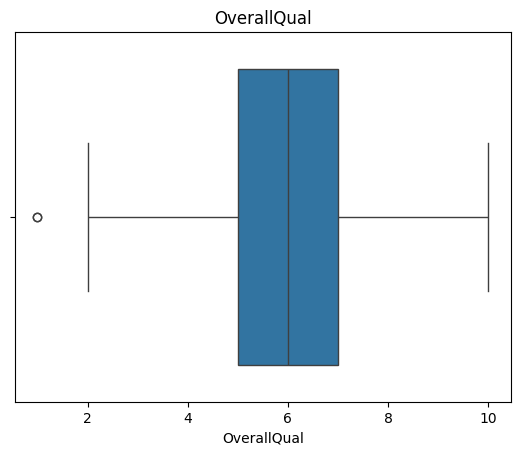

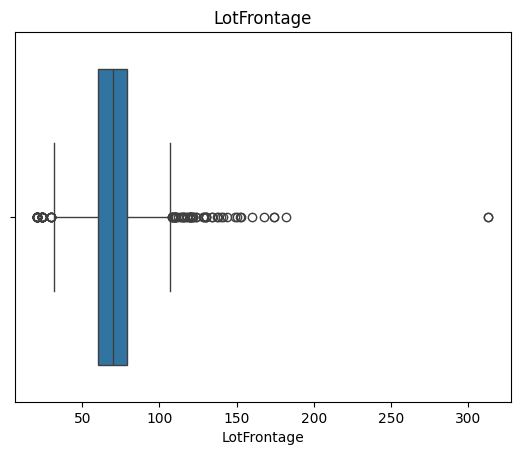

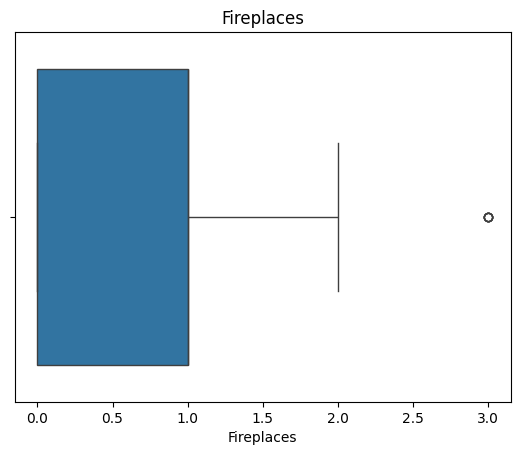

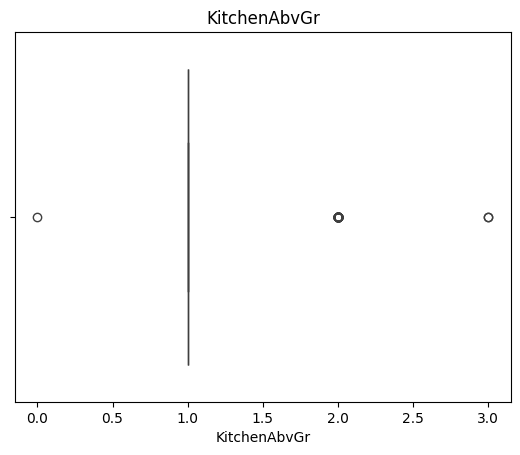

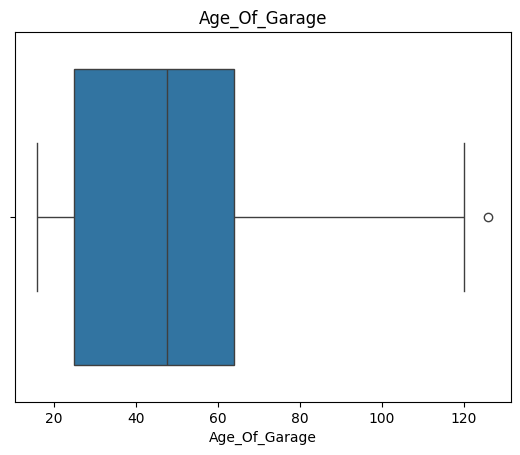

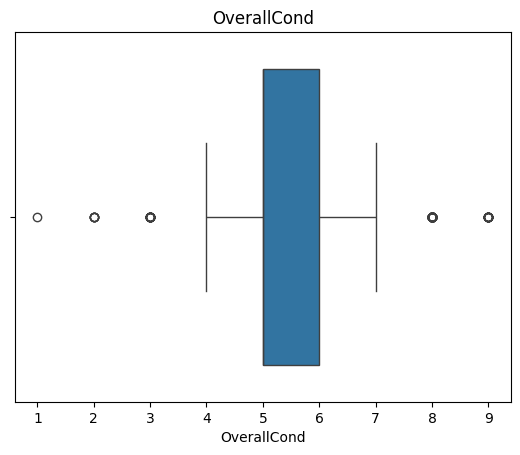

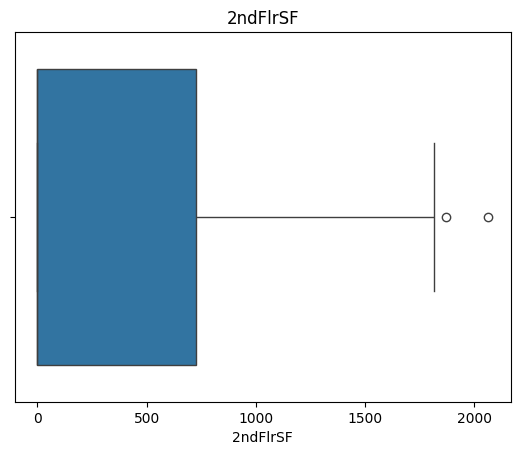

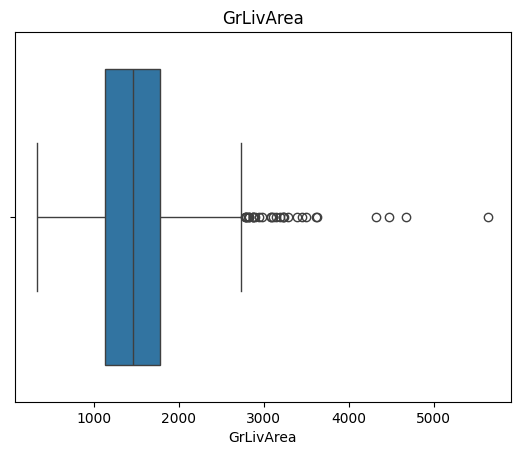

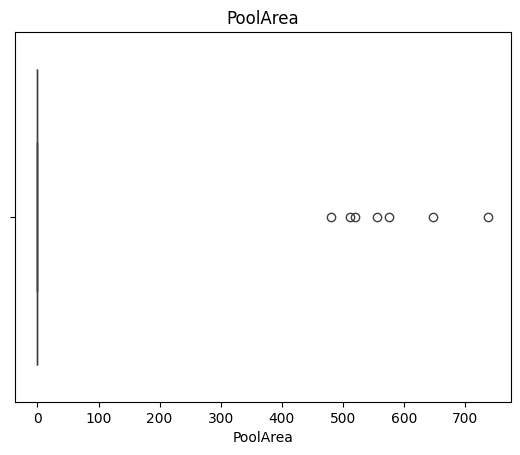

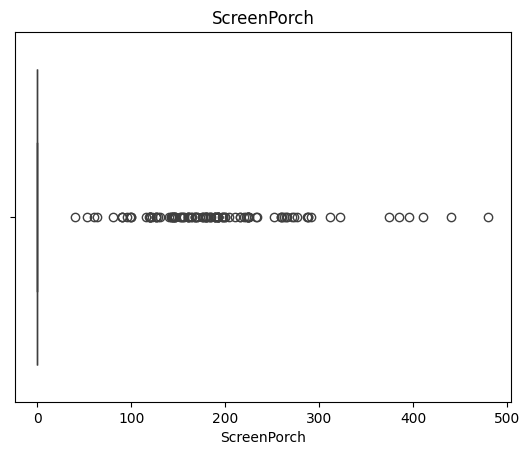

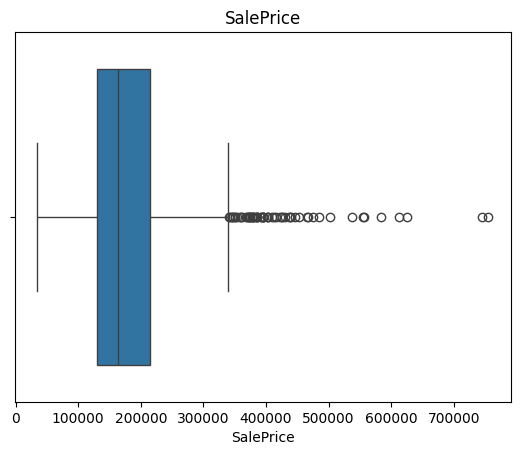

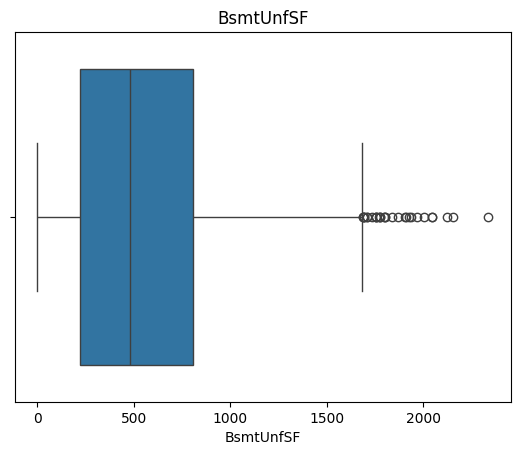

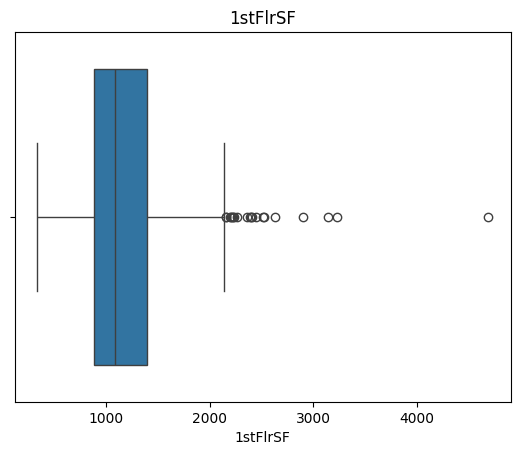

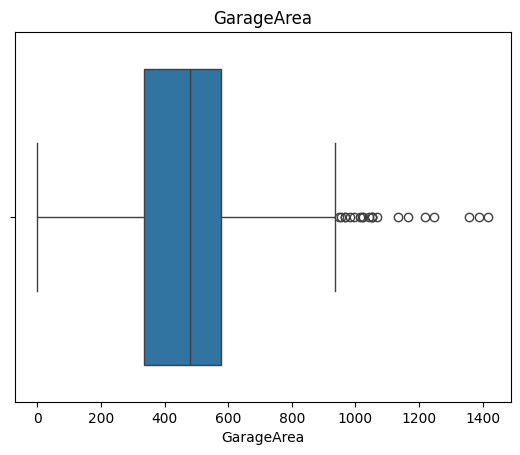

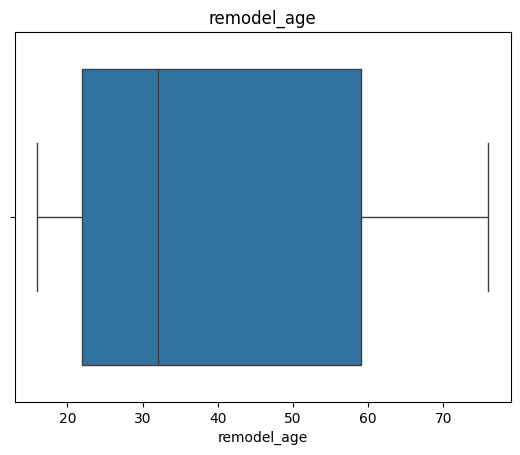

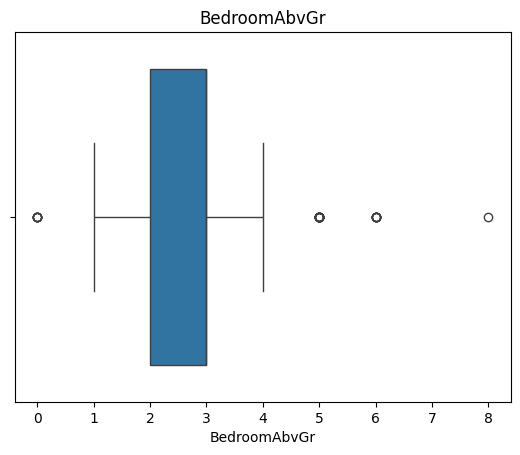

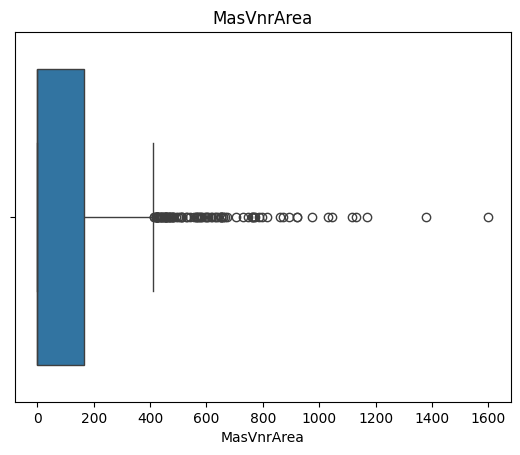

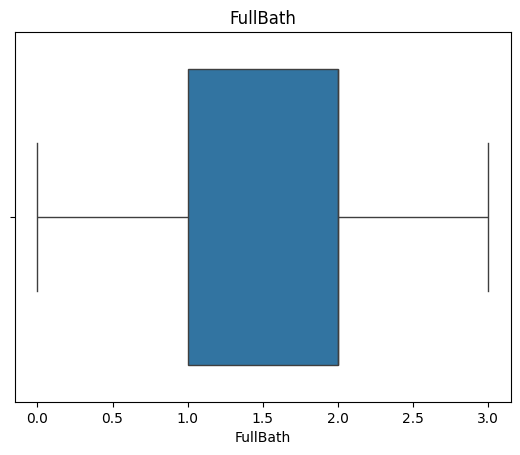

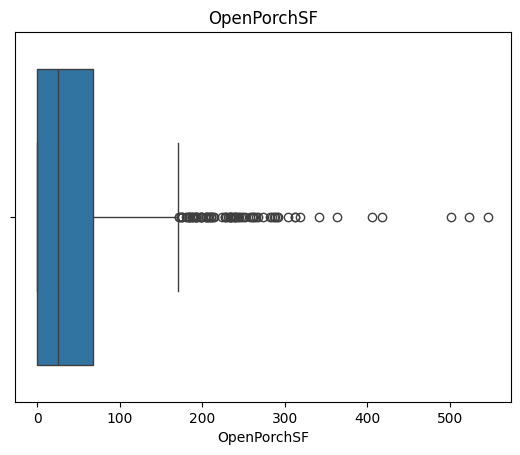

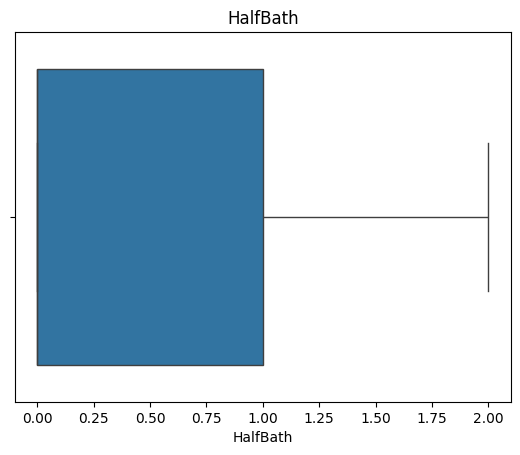

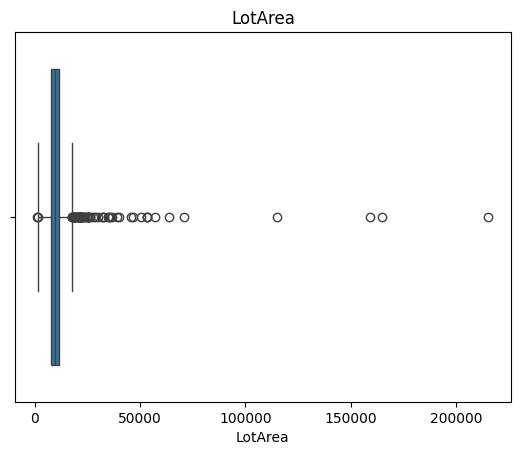

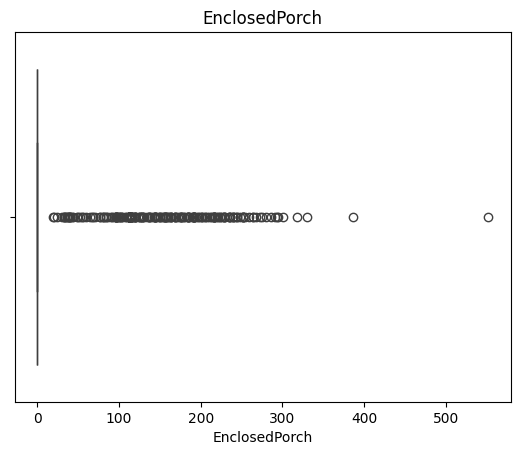

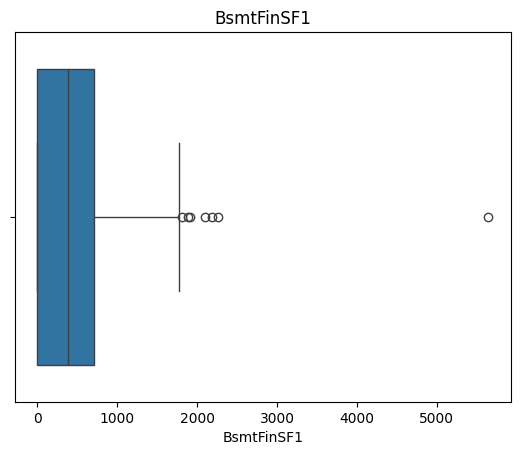

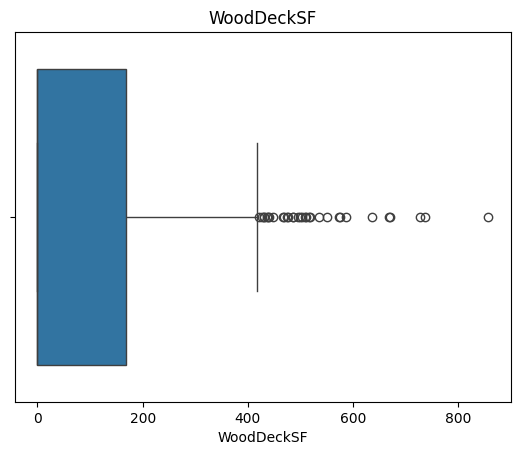

In [32]:
for col in continous_variables:
    sns.boxplot(x=train_data[col])
    plt.title(col)
    plt.show()

In [33]:
num_cols = continous_variables


original_train_data = train_data.copy()
outlier_percentages = {} 
for col in num_cols:   
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = ((train_data[col] < lower) | (train_data[col] > upper)).sum()
    total = len(train_data[col])
    
    percent = (outliers / total) * 100
    outlier_percentages[col] = percent
    
    # Clip values
    train_data[col] = train_data[col].clip(lower, upper)

print(outlier_percentages)
print(outlier_percentages.values())

{'OverallQual': 0.136986301369863, 'LotFrontage': 7.260273972602739, 'Fireplaces': 0.3424657534246575, 'KitchenAbvGr': 4.657534246575342, 'Age_Of_Garage': 0.0684931506849315, 'OverallCond': 8.561643835616438, '2ndFlrSF': 0.136986301369863, 'GrLivArea': 2.1232876712328768, 'PoolArea': 0.4794520547945206, 'ScreenPorch': 7.9452054794520555, 'SalePrice': 4.178082191780822, 'BsmtUnfSF': 1.9863013698630139, '1stFlrSF': 1.36986301369863, 'GarageArea': 1.4383561643835616, 'remodel_age': 0.0, 'BedroomAbvGr': 2.3972602739726026, 'MasVnrArea': 6.712328767123288, 'FullBath': 0.0, 'OpenPorchSF': 5.273972602739726, 'HalfBath': 0.0, 'LotArea': 4.726027397260274, 'EnclosedPorch': 14.246575342465754, 'BsmtFinSF1': 0.4794520547945206, 'WoodDeckSF': 2.191780821917808}
dict_values([0.136986301369863, 7.260273972602739, 0.3424657534246575, 4.657534246575342, 0.0684931506849315, 8.561643835616438, 0.136986301369863, 2.1232876712328768, 0.4794520547945206, 7.9452054794520555, 4.178082191780822, 1.98630136986

### Feature Importance Table

In [34]:
train_data.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtUnfSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
       'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'KitchenQual', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive',
       'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch', 'PoolArea',
       'Fence', 'MoSold', 'SaleType', 'SaleCondition', 'SalePrice',
       'rem

In [35]:
X_train =  train_data.drop("SalePrice", axis=1)
Y_train = train_data[['SalePrice']]

In [36]:
cat_cols = categorical_variables

In [37]:
X_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,OpenPorchSF,EnclosedPorch,ScreenPorch,PoolArea,Fence,MoSold,SaleType,SaleCondition,remodel_age,Age_Of_Garage
0,60,RL,65.0,8450.0,Pave,Not_Available,Reg,Lvl,AllPub,Inside,...,61,0,0,0,Not_Available,2,WD,Normal,23,23.0
1,20,RL,80.0,9600.0,Pave,Not_Available,Reg,Lvl,AllPub,FR2,...,0,0,0,0,Not_Available,5,WD,Normal,50,50.0
2,60,RL,68.0,11250.0,Pave,Not_Available,IR1,Lvl,AllPub,Inside,...,42,0,0,0,Not_Available,9,WD,Normal,24,25.0
3,70,RL,60.0,9550.0,Pave,Not_Available,IR1,Lvl,AllPub,Corner,...,35,0,0,0,Not_Available,2,WD,Abnorml,56,28.0
4,60,RL,84.0,14260.0,Pave,Not_Available,IR1,Lvl,AllPub,FR2,...,84,0,0,0,Not_Available,12,WD,Normal,26,26.0


In [39]:


cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
print(X_train_processed.shape)
print(type(X_train_processed))

(1460, 302)
<class 'numpy.ndarray'>


## Feature Importance for Random Forest Regression
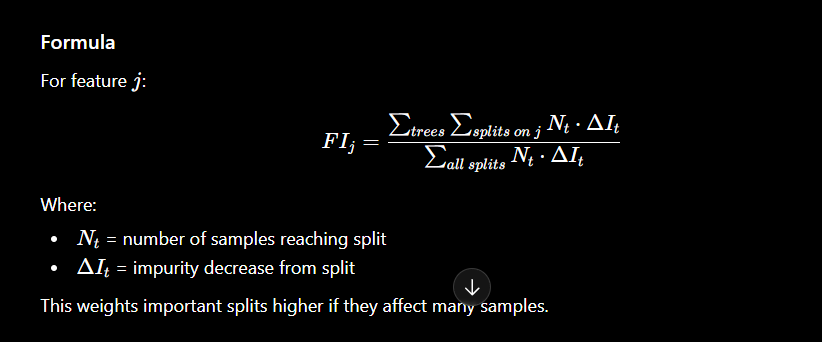

In [40]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train_processed, Y_train)

importance = model.feature_importances_

C:\Users\Ashutosh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1351: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [41]:
feature_names = preprocessor.get_feature_names_out()

from collections import defaultdict
import pandas as pd

grouped_importance = defaultdict(float)

for name, imp in zip(feature_names, importance):
    
    # Split transformer prefix
    transformer, feature = name.split("__", 1)
    
    if transformer == "cat":
        # feature looks like: color_red → get "color"
        base_feature = feature.split("_")[0]
    else:
        # numerical features stay as they are
        base_feature = feature
    
    grouped_importance[base_feature] += imp

grouped_df = pd.DataFrame({
    "feature": list(grouped_importance.keys()),
    "importance": list(grouped_importance.values())
}).sort_values(by="importance", ascending=False)

In [42]:
grouped_df

,feature,importance
46,OverallQual,0.602222
53,GrLivArea,0.117271
59,GarageArea,0.053619
51,1stFlrSF,0.039592
49,BsmtFinSF1,0.032867
45,LotArea,0.014014
65,remodel_age,0.009533
36,GarageFinish,0.007291
22,BsmtQual,0.006854
9,Neighborhood,0.006734


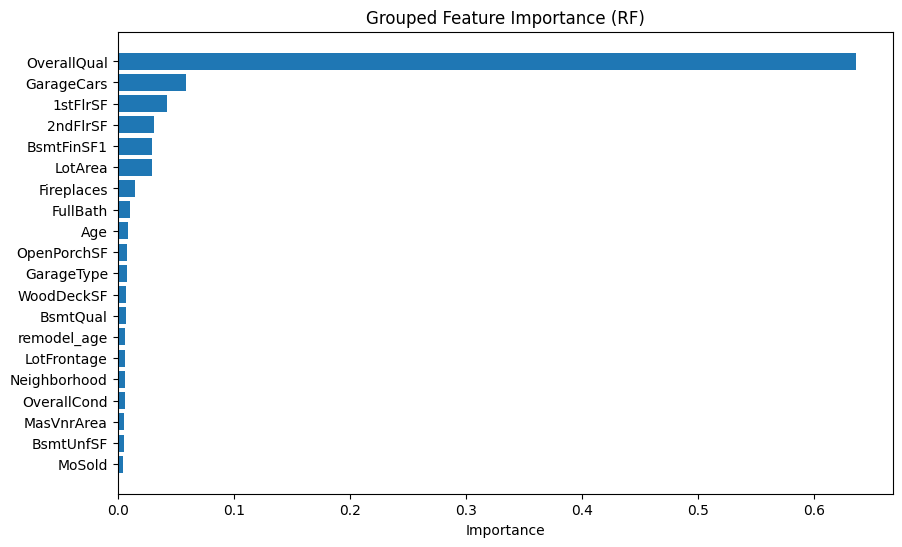

In [35]:
import matplotlib.pyplot as plt

top_20_by_rf = grouped_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_20_by_rf["feature"], top_20_by_rf["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Grouped Feature Importance (RF)")
plt.show()

## Shap Values

In [43]:
import shap
X_train_dense = X_train_processed
explainer_tree = shap.TreeExplainer(model)
shap_values_tree = explainer_tree.shap_values(X_train_dense)

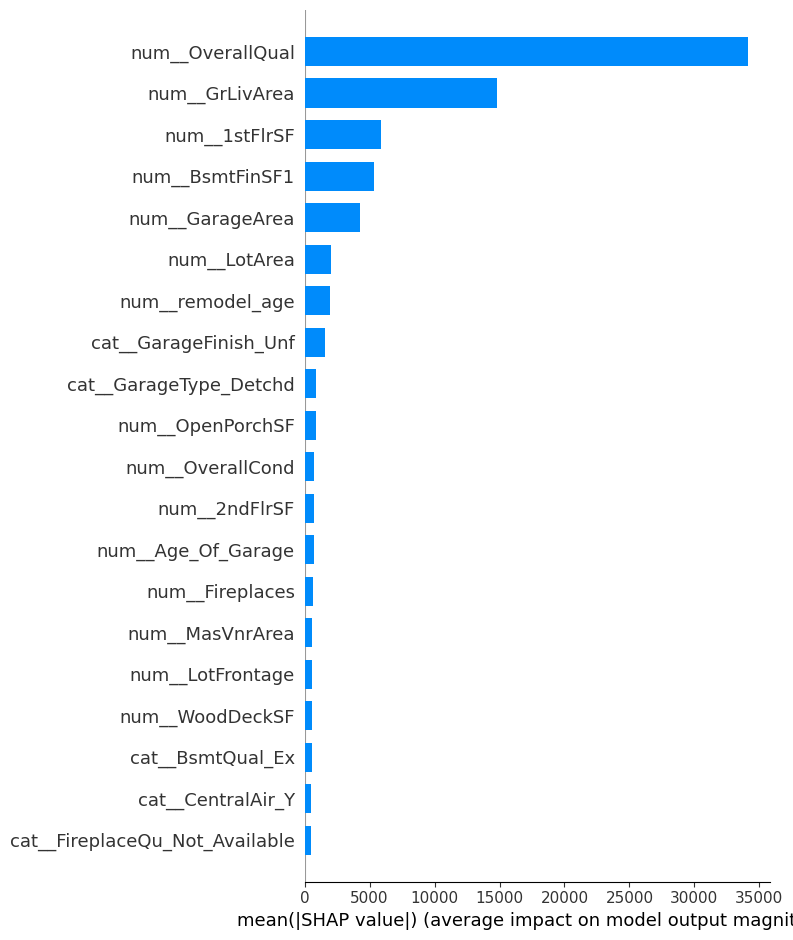

In [44]:
shap.summary_plot(shap_values_tree, X_train_dense, 
                  feature_names=feature_names, plot_type="bar")

In [38]:
shap.force_plot(
    explainer_tree.expected_value,
    shap_values_tree[0],
    feature_names=feature_names
)

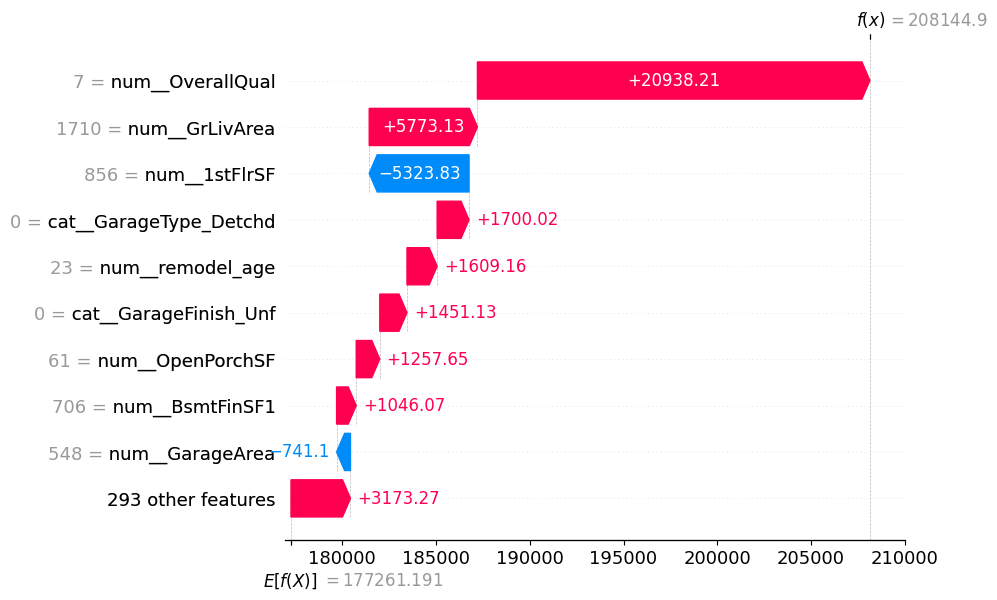

In [45]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_tree[0],
        base_values=explainer_tree.expected_value,
        data=X_train_dense[0],
        feature_names=feature_names
    )
)

In [40]:
shap_importance = np.abs(shap_values_tree).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": feature_names,
    "importance": shap_importance
})

In [41]:
shap_df.head()

,feature,importance
0,cat__MSSubClass_120,21.668480
1,cat__MSSubClass_160,14.584449
2,cat__MSSubClass_180,0.380915
3,cat__MSSubClass_190,3.135674
4,cat__MSSubClass_20,37.085983


In [42]:
from collections import defaultdict

grouped = defaultdict(float)

for _, row in shap_df.iterrows():
    name = row["feature"]
    imp = row["importance"]

    transformer, feature = name.split("__", 1)

    if transformer == "cat":
        for col in cat_cols:
            if feature.startswith(col + "_"):
                grouped[col] += imp
                break
    else:
        grouped[feature] += imp

grouped_df = pd.DataFrame({
    "feature": list(grouped.keys()),
    "importance": list(grouped.values())
}).sort_values(by="importance", ascending=False)

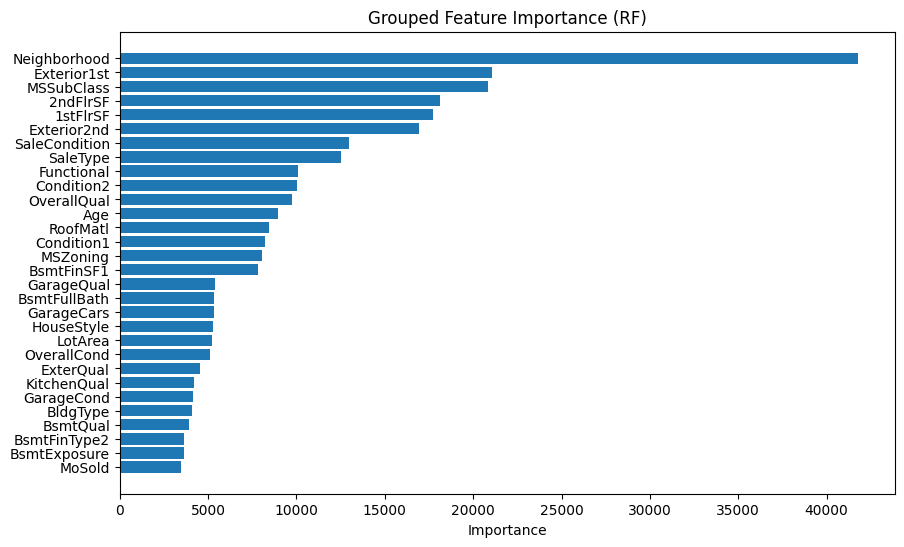

In [111]:
import matplotlib.pyplot as plt

top_20_by_shap_rf = grouped_df.head(30)

plt.figure(figsize=(10, 6))
plt.barh(top_20_by_shap_rf["feature"], top_20_by_shap_rf["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Grouped Feature Importance (RF)")
plt.show()

## Linear Shap Values

In [44]:
from sklearn.linear_model import Ridge

lin_model = Ridge()
lin_model.fit(X_train_processed, Y_train)


Ridge()

In [45]:
explainer_linear = shap.LinearExplainer(lin_model, X_train_processed)
shap_values_linear = explainer_linear.shap_values(X_train_processed)

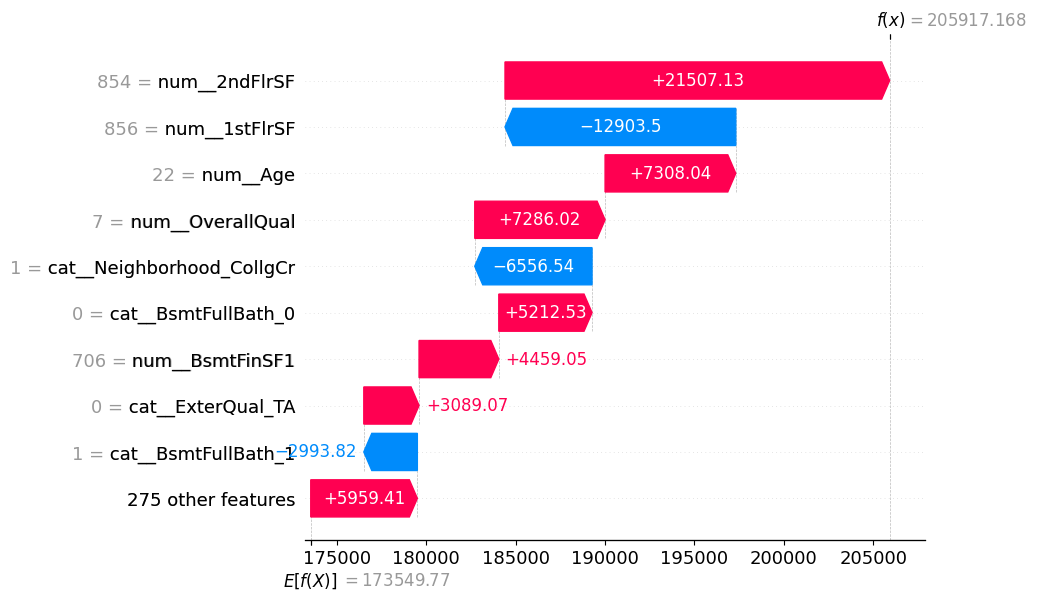

In [46]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_linear[0],
        base_values=explainer_linear.expected_value,
        data=X_train_dense[0],
        feature_names=feature_names
    )
)

In [47]:
shap_importance_linear = np.abs(shap_values_linear).mean(axis=0)
shap_df_linear = pd.DataFrame({
    "feature": feature_names,
    "importance": shap_importance_linear
})


In [48]:
from collections import defaultdict

grouped = defaultdict(float)

for _, row in shap_df_linear.iterrows():
    name = row["feature"]
    imp = row["importance"]

    transformer, feature = name.split("__", 1)

    if transformer == "cat":
        for col in cat_cols:
            if feature.startswith(col + "_"):
                grouped[col] += imp
                break
    else:
        grouped[feature] += imp

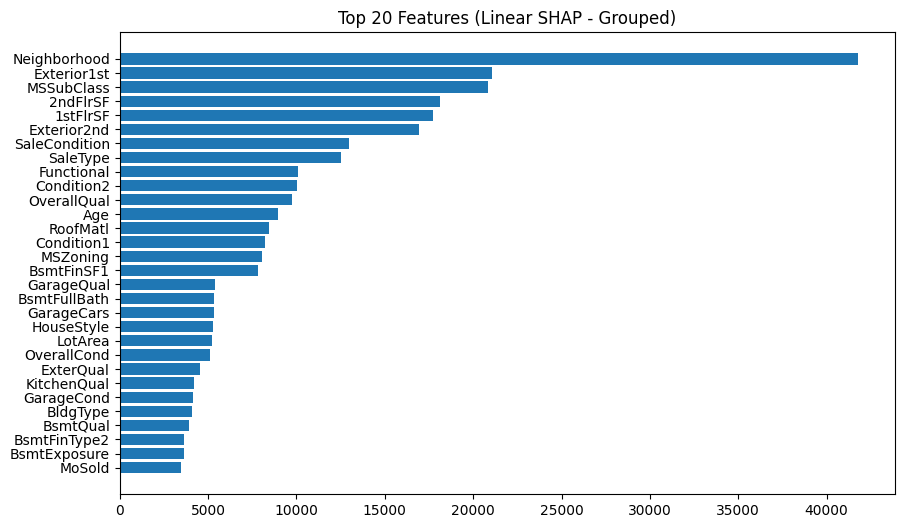

In [110]:

grouped_df_linear = pd.DataFrame({
    "feature": list(grouped.keys()),
    "importance": list(grouped.values())
}).sort_values(by="importance", ascending=False)

top_20_shap_linear = grouped_df_linear.head(30)

plt.figure(figsize=(10, 6))
plt.barh(top_20_shap_linear["feature"], top_20_shap_linear["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (Linear SHAP - Grouped)")
plt.show()

## PDP Values

In [48]:
feature_names = preprocessor.get_feature_names_out()
import pandas as pd

print("Shape just before DF:", X_train_processed.shape)
print("Type:", type(X_train_processed))


X_train_df = pd.DataFrame(
    X_train_dense,
    columns=feature_names
)

Shape just before DF: (1460, 302)
Type: <class 'numpy.ndarray'>


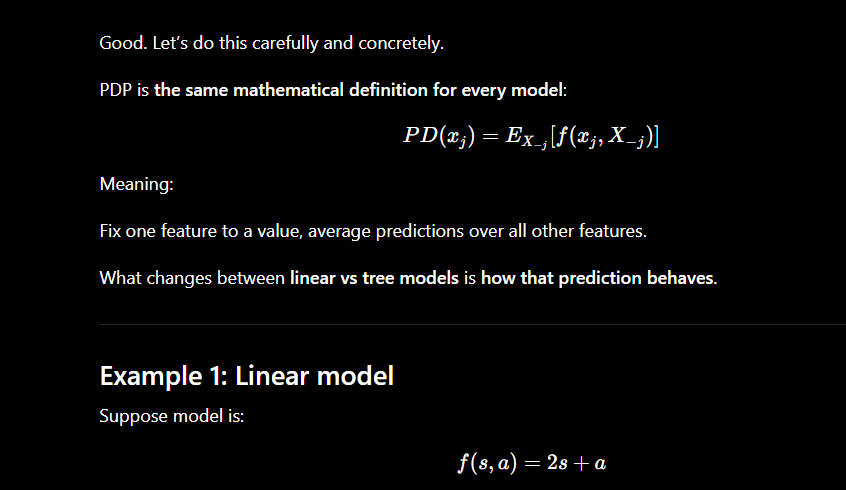

In [69]:
list(X_train_df.columns)

['cat__MSSubClass_120',
 'cat__MSSubClass_160',
 'cat__MSSubClass_180',
 'cat__MSSubClass_190',
 'cat__MSSubClass_20',
 'cat__MSSubClass_30',
 'cat__MSSubClass_40',
 'cat__MSSubClass_45',
 'cat__MSSubClass_50',
 'cat__MSSubClass_60',
 'cat__MSSubClass_70',
 'cat__MSSubClass_75',
 'cat__MSSubClass_80',
 'cat__MSSubClass_85',
 'cat__MSSubClass_90',
 'cat__MSZoning_C (all)',
 'cat__MSZoning_FV',
 'cat__MSZoning_RH',
 'cat__MSZoning_RL',
 'cat__MSZoning_RM',
 'cat__Street_Grvl',
 'cat__Street_Pave',
 'cat__Alley_Grvl',
 'cat__Alley_Not_Available',
 'cat__Alley_Pave',
 'cat__LotShape_IR1',
 'cat__LotShape_IR2',
 'cat__LotShape_IR3',
 'cat__LotShape_Reg',
 'cat__LandContour_Bnk',
 'cat__LandContour_HLS',
 'cat__LandContour_Low',
 'cat__LandContour_Lvl',
 'cat__Utilities_AllPub',
 'cat__Utilities_NoSeWa',
 'cat__LotConfig_Corner',
 'cat__LotConfig_CulDSac',
 'cat__LotConfig_FR2',
 'cat__LotConfig_FR3',
 'cat__LotConfig_Inside',
 'cat__LandSlope_Gtl',
 'cat__LandSlope_Mod',
 'cat__LandSlope_Se

In [70]:
from sklearn.inspection import partial_dependence

pdp_result = partial_dependence(
    model,
    X_train_df,                  
    features=['num__Age_Of_Garage']
)

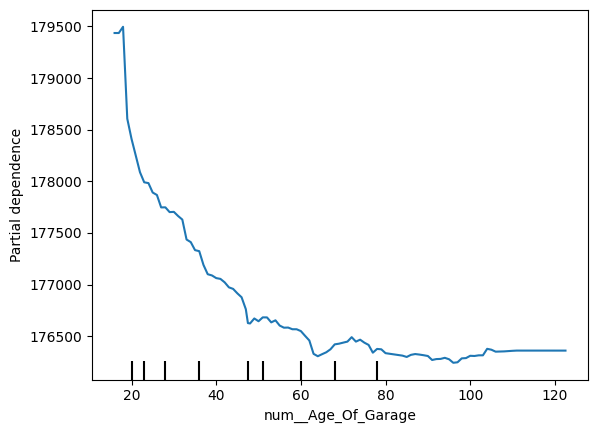

In [72]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(
    model,
    X_train_df,
    ["num__Age_Of_Garage"]
)

In [54]:
values = pdp_result["values"][0]
pdp_vals = pdp_result["average"][0]

In [71]:
pdp_result

{'grid_values': [array([ 16.        ,  17.        ,  18.        ,  19.        ,
          20.        ,  21.        ,  22.        ,  23.        ,
          24.        ,  25.        ,  26.        ,  27.        ,
          28.        ,  29.        ,  30.        ,  31.        ,
          32.        ,  33.        ,  34.        ,  35.        ,
          36.        ,  37.        ,  38.        ,  39.        ,
          40.        ,  41.        ,  42.        ,  43.        ,
          44.        ,  45.        ,  46.        ,  47.        ,
          47.49383611,  48.        ,  49.        ,  50.        ,
          51.        ,  52.        ,  53.        ,  54.        ,
          55.        ,  56.        ,  57.        ,  58.        ,
          59.        ,  60.        ,  61.        ,  62.        ,
          63.        ,  64.        ,  65.        ,  66.        ,
          67.        ,  68.        ,  69.        ,  70.        ,
          71.        ,  72.        ,  73.        ,  74.        ,
          

## LASSO Regression for feature selection

In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_df)

In [56]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)   # you will tune this
lasso.fit(X_scaled, Y_train)

coef = lasso.coef_

C:\Users\Ashutosh\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.522e+10, tolerance: 6.590e+08
  model = cd_fast.enet_coordinate_descent(


In [57]:
selected_features = [
    feature_names[i]
    for i in range(len(coef))
    if coef[i] != 0
]

In [58]:
lasso_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coef
})

lasso_df = lasso_df[lasso_df["coefficient"] != 0]

In [59]:
from collections import defaultdict

grouped = defaultdict(list)

for feat in selected_features:
    transformer, name = feat.split("__", 1)

    if transformer == "cat":
        for col in cat_cols:
            if name.startswith(col + "_"):
                grouped[col].append(feat)
                break
    else:
        grouped[name].append(feat)

In [114]:
## Selecting top 20 features from lasso

In [109]:
lasso_df["abs_coef"] = lasso_df["coefficient"].abs()
lasso_df = lasso_df.sort_values(by="abs_coef", ascending=False)
top_20 = lasso_df.head(30)

In [61]:
from collections import defaultdict

grouped = defaultdict(float)

for _, row in lasso_df.iterrows():
    feat = row["feature"]
    imp = row["abs_coef"]

    transformer, name = feat.split("__", 1)

    if transformer == "cat":
        for col in cat_cols:
            if name.startswith(col + "_"):
                grouped[col] += imp
                break
    else:
        grouped[name] += imp

In [62]:
grouped_df = pd.DataFrame({
    "feature": list(grouped.keys()),
    "importance": list(grouped.values())
}).sort_values(by="importance", ascending=False)

In [63]:
top_20_grouped_by_ridge = grouped_df.head(20)

In [64]:
top_20_grouped_by_ridge

,feature,importance
12,Neighborhood,41761.877780
13,Exterior1st,21073.118521
14,MSSubClass,20858.727042
0,2ndFlrSF,18098.812893
1,1stFlrSF,17698.296284
6,Exterior2nd,16914.246311
10,SaleCondition,12970.809192
4,SaleType,12524.214854
26,Functional,10104.738156
15,Condition2,10043.707014


## Final Selected Features

In [112]:
top_20_features = set(top_20_grouped_by_ridge['feature'].unique()) | set(top_20_shap_linear['feature'].unique()) | set(top_20_by_shap_rf['feature'].unique()) | set(top_20_by_rf['feature'].unique())

In [113]:
final_feat_list = list(top_20_features) + ["SalePrice"]
final_feat_list

['Exterior2nd',
 'Age',
 'GarageQual',
 'GarageCond',
 'BsmtFinType2',
 'MoSold',
 '2ndFlrSF',
 'GarageCars',
 'Exterior1st',
 'RoofMatl',
 'BsmtFullBath',
 'HouseStyle',
 'LotArea',
 'BsmtExposure',
 'MasVnrArea',
 'Functional',
 'FullBath',
 'Condition1',
 '1stFlrSF',
 'OverallCond',
 'BsmtQual',
 'SaleType',
 'KitchenQual',
 'OverallQual',
 'GarageType',
 'WoodDeckSF',
 'Neighborhood',
 'SaleCondition',
 'ExterQual',
 'BldgType',
 'OpenPorchSF',
 'Fireplaces',
 'BsmtFinSF1',
 'remodel_age',
 'Condition2',
 'MSZoning',
 'LotFrontage',
 'MSSubClass',
 'BsmtUnfSF',
 'SalePrice']

In [114]:
train_data_selected = train_data[final_feat_list]
train_data_selected.to_csv("./HousePriceRegression_TrainData.csv")

## Run XGBoost

In [115]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [173]:
X = train_data_selected[list(top_20_features)]
y = train_data_selected["SalePrice"]

In [174]:

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=1234
)

## Params to optimize for XGBoost

| Parameter               | Category         | Type               | Description                             | Typical Values / Notes                                        |
| ----------------------- | ---------------- | ------------------ | --------------------------------------- | ------------------------------------------------------------- |
| `booster`               | Core             | hyperparameter     | Model type                              | `"gbtree"`, `"gblinear"`, `"dart"`                            |
| `objective`             | Core             | hyperparameter     | Loss function                           | `"reg:squarederror"`, `"binary:logistic"`, `"multi:softprob"` |
| `eval_metric`           | Core             | hyperparameter     | Evaluation metric                       | `"rmse"`, `"logloss"`, `"auc"`, `"mae"`                       |
| `max_depth`             | Tree structure   | hyperparameter     | Max depth of tree                       | 3–10 typical                                                  |
| `min_child_weight`      | Tree structure   | hyperparameter     | Minimum sum of instance weight in child | Higher = more conservative                                    |
| `max_leaves`            | Tree structure   | hyperparameter     | Max leaves allowed                      | Used with lossguide                                           |
| `grow_policy`           | Tree structure   | hyperparameter     | Tree growth strategy                    | `"depthwise"`, `"lossguide"`                                  |
| `subsample`             | Sampling         | hyperparameter     | Row sampling per tree                   | 0.5–1.0                                                       |
| `colsample_bytree`      | Sampling         | hyperparameter     | Feature fraction per tree               | 0.5–1.0                                                       |
| `colsample_bylevel`     | Sampling         | hyperparameter     | Feature fraction per level              | Fine-grained control                                          |
| `colsample_bynode`      | Sampling         | hyperparameter     | Feature fraction per split              | Most granular                                                 |
| `learning_rate` (eta)   | Boosting         | hyperparameter     | Step size shrinkage                     | 0.01–0.3                                                      |
| `n_estimators`          | Boosting         | hyperparameter     | Number of trees                         | 100–2000                                                      |
| `gamma`                 | Boosting         | hyperparameter     | Min loss reduction to split             | Higher = more pruning                                         |
| `reg_alpha`             | Regularization   | hyperparameter     | L1 regularization                       | Encourages sparsity                                           |
| `reg_lambda`            | Regularization   | hyperparameter     | L2 regularization                       | Smooths weights                                               |
| `max_delta_step`        | Regularization   | hyperparameter     | Limits weight update                    | Used in logistic stability                                    |
| `scale_pos_weight`      | Imbalance        | hyperparameter     | Balances positive class                 | Useful for skewed data                                        |
| `n_jobs`                | System           | system parameter   | Parallel threads                        | CPU utilization                                               |
| `tree_method`           | System           | system parameter   | Tree construction algorithm             | `"auto"`, `"hist"`, `"gpu_hist"`                              |
| `device`                | System           | system parameter   | Compute device                          | `"cpu"`, `"cuda"`                                             |
| `verbosity`             | System           | system parameter   | Logging level                           | 0–3                                                           |
| `early_stopping_rounds` | Training control | training parameter | Stops if no improvement                 | Prevents overfitting                                          |
| `eval_set`              | Training control | training parameter | Validation dataset                      | Required for early stopping                                   |
| `verbose`               | Training control | training parameter | Print logs                              | Debugging                                                     |
| `missing`               | Data handling    | system parameter   | Missing value indicator                 | Default: NaN                                                  |
| `enable_categorical`    | Data handling    | system parameter   | Native categorical support              | Needs hist tree method                                        |
| `num_class`             | Multi-class      | hyperparameter     | Number of classes                       | Used in classification                                        |


colsample_bytree → random features per tree
colsample_bylevel → random features per depth
colsample_bynode → random features per split

More granular → more randomness → more regularization

In [168]:
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=1234,
    enable_categorical=True
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=1234, ...)

In [169]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 23335.196092045142
R2 Score: 0.8795977125744767


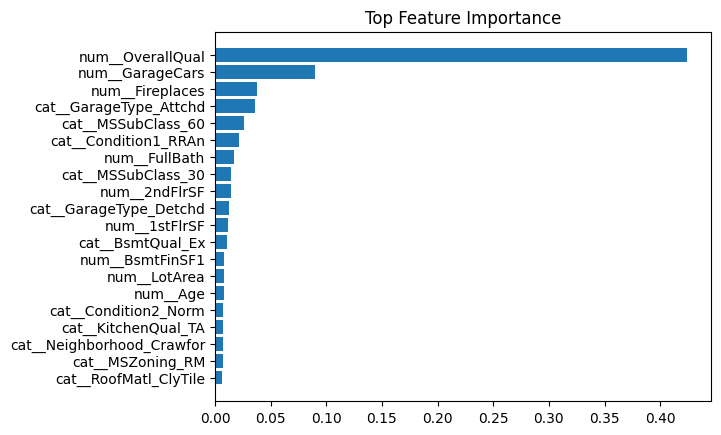

In [170]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Get importance
importance = model.feature_importances_

# Convert to DataFrame for easy handling
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Sort
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# Plot top 20
plt.barh(feat_imp["feature"][:20], feat_imp["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance")
plt.show()

In [123]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 6, 10],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

grid = GridSearchCV(
    estimator=XGBRegressor(objective="reg:squarederror", random_state=1234),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

Fitting 3 folds for each of 72 candidates, totalling 216 fits


GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=1234, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 6, 10], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1.0]},
             scoring='neg_mean_squared_error', verbose=1)

In [124]:
best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)

Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Tuned RMSE: 21827.27894072282
Tuned R2: 0.8946557039413182


In [125]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape)

MAPE: 9.625294854827107


## ADA Boost


In [126]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [171]:
# Base model (weak learner)
base_model = DecisionTreeRegressor(max_depth=5)

# AdaBoost model
model = AdaBoostRegressor(
    estimator=base_model,   # earlier versions use base_estimator
    n_estimators=50,
    learning_rate=0.3,
    random_state=1234
)

# Train
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, preds))

mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print("MAPE:", mape)

MSE: 796887324.1567131
MAPE: 13.607368394669908


| Parameter                                         | Meaning                                         | Effect if Increased                                  |
| ------------------------------------------------- | ----------------------------------------------- | ---------------------------------------------------- |
| **n_estimators**                                  | Number of weak learners (usually shallow trees) | More complex model, lower bias, possible overfit     |
| **learning_rate**                                 | Shrinks contribution of each learner            | Lower = slower learning, often better generalization |
| **estimator** (or `base_estimator` older sklearn) | Weak learner used                               | Controls model complexity                            |
| **algorithm**                                     | Boosting variant (`SAMME`, `SAMME.R`)           | Changes weight update rule                           |
| **random_state**                                  | Reproducibility                                 | No model effect                                      |


| Parameter             | Meaning                           | Effect                                 |
| --------------------- | --------------------------------- | -------------------------------------- |
| **max_depth**         | Tree depth                        | Higher = stronger learner, can overfit |
| **min_samples_split** | Min samples to split node         | Higher = regularization                |
| **min_samples_leaf**  | Min samples in leaf               | Smooths predictions                    |
| **max_leaf_nodes**    | Limits leaves                     | Controls complexity                    |
| **criterion**         | Split quality (`gini`, `entropy`) | Usually minor effect                   |


In [128]:
# Parameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1],
    "estimator__max_depth": [1, 2, 3, 5]
}

# Grid search
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Fit
grid.fit(X_train, y_train)

# Best results
print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'estimator__max_depth': 5, 'learning_rate': 1, 'n_estimators': 200}
Best Score: -550075678.2922996


In [129]:
best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)

Best Params: {'estimator__max_depth': 5, 'learning_rate': 1, 'n_estimators': 200}


In [143]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)


mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print("MAPE:", mape)

Tuned RMSE: 22932.829932023305
Tuned R2: 0.883714081090863
MAPE: 10.178959605344685


In [131]:

mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print("MAPE:", mape)

MAPE: 13.607368394669908


## Light GBM

In [134]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV

In [135]:
model = LGBMRegressor(random_state=1234)

In [136]:
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "num_leaves": [31, 50],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1]
}

## Light GBM Param and Hyperparam

| Parameter       | Category | Type           | Description       | Typical Values / Notes                     |
| --------------- | -------- | -------------- | ----------------- | ------------------------------------------ |
| `boosting_type` | Core     | hyperparameter | Type of boosting  | `"gbdt"`, `"dart"`, `"goss"`, `"rf"`       |
| `objective`     | Core     | hyperparameter | Loss function     | `"regression"`, `"binary"`, `"multiclass"` |
| `metric`        | Core     | hyperparameter | Evaluation metric | `"rmse"`, `"auc"`, `"logloss"`             |


| Parameter                 | Category       | Type           | Description               | Notes                           |
| ------------------------- | -------------- | -------------- | ------------------------- | ------------------------------- |
| `num_leaves`              | Tree structure | hyperparameter | Maximum leaves per tree   | ⭐ MOST IMPORTANT parameter      |
| `max_depth`               | Tree structure | hyperparameter | Max depth (-1 = no limit) | Controls overfitting indirectly |
| `min_data_in_leaf`        | Tree structure | hyperparameter | Minimum samples per leaf  | Very important for overfitting  |
| `min_sum_hessian_in_leaf` | Tree structure | hyperparameter | Minimum hessian in leaf   | Smoother splits                 |
| `max_bin`                 | Tree structure | hyperparameter | Discretization bins       | Impacts speed + accuracy        |


| Parameter          | Category | Type           | Description                   | Notes               |
| ------------------ | -------- | -------------- | ----------------------------- | ------------------- |
| `subsample`        | Sampling | hyperparameter | Row sampling fraction         | Reduces overfitting |
| `subsample_freq`   | Sampling | hyperparameter | How often subsampling happens | e.g. 1 = every tree |
| `colsample_bytree` | Sampling | hyperparameter | Feature sampling per tree     | Very important      |
| `colsample_bynode` | Sampling | hyperparameter | Feature sampling per split    | Fine control        |


| Parameter              | Category | Type           | Description               | Notes                     |
| ---------------------- | -------- | -------------- | ------------------------- | ------------------------- |
| `learning_rate`        | Boosting | hyperparameter | Step size shrinkage       | Lower = more trees needed |
| `n_estimators`         | Boosting | hyperparameter | Number of boosting rounds | More trees = better fit   |
| `early_stopping_round` | Training | control        | Stop if no improvement    | Prevents overfitting      |


| Parameter           | Category       | Type           | Description                    |
| ------------------- | -------------- | -------------- | ------------------------------ |
| `lambda_l1`         | Regularization | hyperparameter | L1 regularization              |
| `lambda_l2`         | Regularization | hyperparameter | L2 regularization              |
| `min_gain_to_split` | Regularization | hyperparameter | Minimum gain required to split |


| Parameter | Category | Type   | Description      |
| --------- | -------- | ------ | ---------------- |
| `device`  | System   | system | CPU / GPU        |
| `n_jobs`  | System   | system | Parallel threads |
| `verbose` | System   | system | Logging level    |


| Boosting Type | Full Form                               | Simple Definition                                                                           | How It Works                                                        | Best Use Case                           |
| ------------- | --------------------------------------- | ------------------------------------------------------------------------------------------- | ------------------------------------------------------------------- | --------------------------------------- |
| **`gbdt`**    | Gradient Boosting Decision Trees        | Standard boosting where each new tree fixes previous errors                                 | Trees are built **sequentially**, each correcting residual errors   | Default choice for most problems        |
| **`dart`**    | Dropouts meet Additive Regression Trees | GBDT + randomly drops some old trees during training to reduce overfitting                  | Some previous trees are ignored temporarily while training new ones | Noisy datasets / overfitting problems   |
| **`goss`**    | Gradient-based One-Side Sampling        | Trains faster by keeping important high-error samples and sampling fewer easy ones          | Focuses learning on rows with large gradients (large mistakes)      | Very large datasets where speed matters |
| **`rf`**      | Random Forest                           | Builds independent trees and averages predictions instead of correcting errors sequentially | Trees train separately on random samples/features                   | Stable baseline, lower overfitting      |


In [137]:
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1971
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 128
[LightGBM] [Info] Start training from score 177608.729880
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [138]:
best_model = grid.best_estimator_

preds = best_model.predict(X_test)

In [144]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)


mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print("MAPE:", mape)

Tuned RMSE: 22932.829932023305
Tuned R2: 0.883714081090863
MAPE: 10.178959605344685


## CATBOOST

In [147]:
from catboost import CatBoostRegressor

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

model = CatBoostRegressor(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

| Parameter               | Meaning                          | Effect if Increased                         |
| ----------------------- | -------------------------------- | ------------------------------------------- |
| **iterations**          | Number of trees                  | More complexity, can overfit                |
| **learning_rate**       | Shrinks each tree contribution   | Lower = slower, often better generalization |
| **depth**               | Tree depth                       | Higher = more complex interactions          |
| **l2_leaf_reg**         | L2 regularization on leaf values | Higher = smoother, less overfit             |
| **loss_function**       | Objective to optimize            | Defines learning target                     |
| **eval_metric**         | Validation metric                | Controls model selection                    |
| **random_strength**     | Noise added to split scoring     | Higher = stronger regularization            |
| **bagging_temperature** | Sampling aggressiveness          | Higher = more randomness                    |
| **border_count**        | Numeric feature bin count        | Higher = finer splits, slower               |
| **min_data_in_leaf**    | Min samples per leaf             | Higher = simpler trees                      |
| **subsample**           | Fraction of rows used            | More regularization if lower                |
| **rsm**                 | Fraction of features per split   | Feature subsampling                         |
| **grow_policy**         | Tree growth strategy             | Controls structure                          |
| **cat_features**        | Categorical columns              | Enables native categorical encoding         |


In [177]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)


mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print("MAPE:", mape)

Tuned RMSE: 21627.597487752613
Tuned R2: 0.8965743200025734
MAPE: 9.959015337894133


In [178]:
param_grid = {
    "iterations": [100, 200],
    "depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

In [179]:

grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=CatBoostRegressor(depth=6, iterations=200, learning_rate=0.1, loss_function='RMSE', verbose=0),
             n_jobs=-1,
             param_grid={'depth': [4, 6, 8], 'iterations': [100, 200],
                         'learning_rate': [0.05, 0.1]},
             scoring='neg_mean_squared_error')

In [180]:
print(grid.best_params_)

{'depth': 6, 'iterations': 200, 'learning_rate': 0.1}


In [181]:
best_model = grid.best_estimator_

preds = best_model.predict(X_test)

In [182]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned RMSE:", rmse)
print("Tuned R2:", r2)


mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print("MAPE:", mape)

Tuned RMSE: 21627.597487752613
Tuned R2: 0.8965743200025734
MAPE: 9.959015337894133


## Comparison of different boosting algorithms

| Dimension                      | AdaBoost                                                  | XGBoost                                          | LightGBM                                                 | CatBoost                                                  |
| ------------------------------ | --------------------------------------------------------- | ------------------------------------------------ | -------------------------------------------------------- | --------------------------------------------------------- |
| **Core idea**                  | Focus on correcting misclassified samples via reweighting | Gradient boosting with second-order optimization | Fast gradient boosting with histogram + leaf-wise growth | Gradient boosting with ordered boosting + symmetric trees |
| **How trees are built**        | Many weak learners (usually stumps) trained sequentially  | Full CART trees built using gradient + Hessian   | Full CART trees built leaf-wise (best split first)       | Symmetric (oblivious) trees with same split at each level |
| **Tree complexity**            | Very shallow (weak learners)                              | Medium to deep                                   | Deep and irregular                                       | Controlled, balanced depth                                |
| **Learning mechanism**         | Increases weight of misclassified points                  | Minimizes loss using gradients                   | Minimizes loss using gradients efficiently               | Minimizes loss using ordered (leakage-safe) gradients     |
| **Focus of learning**          | Hard-to-classify points                                   | Overall loss reduction                           | Hard-to-improve regions in feature space                 | Stable learning without target leakage                    |
| **Ensemble style**             | Weighted voting of weak classifiers                       | Additive model of trees                          | Additive model of trees                                  | Additive model of symmetric trees                         |
| **Speed**                      | Fast (small models only)                                  | Fast                                             | ⭐ Very fast (best for large data)                        | Medium-fast                                               |
| **Scalability**                | Poor                                                      | Good                                             | ⭐ Excellent                                              | Good                                                      |
| **Handling large datasets**    | Not suitable                                              | Good                                             | ⭐ Best choice                                            | Good                                                      |
| **Categorical features**       | Requires encoding                                         | Needs encoding                                   | Native support (basic)                                   | ⭐ Best-in-class native handling                           |
| **Missing values**             | Not robust                                                | Handles internally                               | Handles internally                                       | Handles internally                                        |
| **Overfitting tendency**       | Medium–High                                               | Low–Medium (well regularized)                    | Medium (leaf-wise risk)                                  | Low–Medium (very stable)                                  |
| **Regularization strength**    | Weak                                                      | ⭐ Strong (L1, L2, gamma)                         | Strong but indirect                                      | Strong (L2 + randomness + ordering)                       |
| **Tree growth strategy**       | Stump / shallow trees                                     | Level-wise or depth-wise                         | ⭐ Leaf-wise (Lossguide)                                  | Symmetric (level-wise fixed splits)                       |
| **Split selection**            | Error-driven reweighting                                  | Gain (loss reduction + Hessian)                  | Gain-based best leaf split                               | Gain + ordered statistics                                 |
| **Interpretability**           | Medium (simple rules)                                     | Medium                                           | Low–Medium                                               | Medium                                                    |
| **Training stability**         | Medium                                                    | High                                             | Medium                                                   | ⭐ Very high (ordering reduces leakage)                    |
| **Data leakage control**       | Not applicable                                            | Medium                                           | Medium                                                   | ⭐ Excellent (ordered boosting)                            |
| **Best use case**              | Small datasets, baseline models                           | General-purpose strong model                     | Large-scale ML, speed-critical systems                   | Categorical-heavy datasets, competitions                  |
| **Weakness**                   | Too simple, underperforms                                 | Slower than LightGBM                             | Can overfit due to leaf-wise growth                      | Slower than LightGBM, more memory                         |
| **Default choice in industry** | Rare today                                                | ⭐ Very common                                    | Very common in large-scale systems                       | Increasingly popular in categorical problems              |


| Model    | One-line intuition                                              |
| -------- | --------------------------------------------------------------- |
| AdaBoost | “Fix mistakes by reweighting samples”                           |
| XGBoost  | “Optimize loss precisely with strong regularization”            |
| LightGBM | “Speed-optimized greedy leaf-wise boosting”                     |
| CatBoost | “Leakage-safe symmetric boosting with categorical intelligence” |
